# WO6b — Compare the curve, not its summaries

Work order: `docs/cdop/pilot/wo6b_compare-curves.md`. Prior: `wo6a_findings.md`, `wo5_findings.md`, `wo2a_findings.md`.

Every similarity attempt in this project has compressed twelve monthly values into two to five derived scalars and compared those, and the failures have consistently occurred *in the compression*. This notebook tests not making it: compare the twelve-value curve directly.

**Papers on disk** (`articles/`), both read and their formulations reproduced here:

- Knoben, Woods & Freer (2019), *Global bimodal precipitation seasonality* — Part C.
- Berghuijs & Woods (2016), *A simple framework to quantitatively describe monthly precipitation and temperature climatology* — the parent framework Knoben builds on. Supplies two things WO6b did not have: `delta_P`, a **dimensionless** precipitation seasonality amplitude, and `s_d`, the precipitation–temperature phase difference.

**Two additions to the WO, made here and flagged for the findings:**

1. **Part D gains an amplitude condition.** WO6b Part A states that correlation is scale-free "which is why magnitude *and amplitude* must be separate conditions (Part D)" — but Part D lists only shape, magnitude and temperature. Two basins at ~1000 mm/yr, both summer-peaking, one temperate-maritime and one sharp monsoon, would pass every condition Part D names. B&W's `delta_P` is exactly the missing term.
2. **Part E gains `s_d`.** The precipitation–temperature phase difference is hemisphere-blind by construction (a Mediterranean regime reads the same in both hemispheres) without maximising over circular shifts. Reported alongside the WO's shift method, not instead of it.

**Sequencing.** Part A is a gate. If pairwise profile correlation does not discriminate, that closes this line and the rest is moot — a legitimate outcome, per the WO's accept gate.

In [1]:
# Cell 1 — Setup
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import pyogrio
from IPython.display import Image as IPImage
from scipy.optimize import minimize

from scripts.shared import db_utils

conn = db_utils.db_connect()
ROOT = Path(db_utils.__file__).parent.parent.parent
OUT  = ROOT / 'output' / 'cdop'
OUT.mkdir(parents=True, exist_ok=True)

WORLD = gpd.read_file(Path(pyogrio.__file__).parent / 'tests/fixtures/naturalearth_lowres/naturalearth_lowres.shp')

MONTH_LETTERS = list('JFMAMJJASOND')
month_x = np.arange(12)

# THRESH_ARID = 100 mm/yr -- the one threshold in this project sitting in a genuine histogram
# trough, robust to +/-25 mm (wo2_findings.md Cell 12). Below this a monthly profile is
# noise-dominated and its correlation with anything is meaningless.
THRESH_ARID = 100.0

print("Setup complete.")

Setup complete.


In [2]:
# Cell 2 — Corpus load, L06: monthly arrays + scalars + representative points
# Same load pattern as WO6a Cell 5 (ST_PointOnSurface, not ST_Centroid; -9999 sentinel masked
# against the raw column before scaling).
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

arr = pd.read_sql(
    "SELECT hybas_id, pre_mm_monthly, tmp_dc_monthly, zone_name, biome "
    "FROM public.v_basin06_persist_rev2", conn)
sc = pd.read_sql(
    "SELECT hybas_id, pre_mm_syr, tmp_dc_syr, "
    "ST_Y(ST_PointOnSurface(geom)) AS lat, ST_X(ST_PointOnSurface(geom)) AS lon "
    "FROM public.basin06", conn)
arr['hybas_id'] = arr['hybas_id'].astype(np.int64)
sc['hybas_id']  = sc['hybas_id'].astype(np.int64)
df = arr.merge(sc, on='hybas_id', how='left')

PRE_all = np.array(df['pre_mm_monthly'].tolist(), dtype=float)
TMP_all = np.array(df['tmp_dc_monthly'].tolist(), dtype=float)   # already deg C, per seasonality.py

for col, scale in (('pre_mm_syr', 1.0), ('tmp_dc_syr', 0.1)):
    df[col] = df[col].astype(float)
    df.loc[df[col] == -9999 * scale, col] = np.nan
    df[col] = df[col] * scale

df['pre_total']    = PRE_all.sum(axis=1)
df['tmp_seas_amp'] = TMP_all.max(axis=1) - TMP_all.min(axis=1)

valid = (~np.isnan(PRE_all).any(axis=1) & ~np.isnan(TMP_all).any(axis=1)
         & (df['pre_total'] > 0) & df['tmp_dc_syr'].notna())
valid = valid.to_numpy()

df  = df[valid].reset_index(drop=True)
PRE = PRE_all[valid]
TMP = TMP_all[valid]

print(f"L06 valid: {len(df)} of {len(valid)} basins")
print(f"arid (< {THRESH_ARID:.0f} mm/yr): {(df['pre_total'] < THRESH_ARID).sum()} "
      f"({100*(df['pre_total'] < THRESH_ARID).mean():.1f}%) -- excluded from correlation work")

L06 valid: 16338 of 16397 basins
arid (< 100 mm/yr): 1434 (8.8%) -- excluded from correlation work


In [4]:
# Cell 3 — Probes
# WO4's set + Yakutsk (WO6a's high-latitude probe) + the two basins WO6a pinned by hybas_id:
# Somalia (asymmetric two-monsoon Gu/Deyr) and Tennessee (March/December peaks ~9 months apart,
# the case no harmonic-ratio measure can detect in principle).
# Nairobi added here: Somalia's L06 basin turns out to be 87 mm/yr -- arid-gated, so it cannot
# participate in the correlation population at all. Nairobi carries the same East African
# two-rains signal (long rains Mar-May, short rains Oct-Dec) at a workable annual total, so
# Parts B-D have a testable bimodal case inside the eligible corpus.
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

PROBE_POINTS = [
    ('Mombasa',      -4.0435,   39.6682),
    ('Augsburg',     48.3705,   10.8978),
    ('Tbilisi',      41.6938,   44.8015),
    ('Kaifeng',      34.7986,  114.3413),
    ('Timbuktu',     16.8167,   -2.9833),
    ('George Town',   5.4141,  100.3288),
    ('Santiago',    -33.4489,  -70.6693),
    ('Yakutsk',      62.0280,  129.7326),
    ('Nairobi',      -1.2864,   36.8172),
]
PROBE_IDS = [('Somalia', 1060006860), ('Tennessee', 7060610850)]

def resolve_basin(lat, lon):
    row = pd.read_sql(
        "SELECT hybas_id FROM basin06 "
        f"WHERE ST_Within(ST_SetSRID(ST_MakePoint({lon}, {lat}), 4326), geom) "
        "ORDER BY ST_Area(geom::geography) ASC LIMIT 1", conn)
    return None if row.empty else int(row.iloc[0]['hybas_id'])

pos = {h: i for i, h in enumerate(df['hybas_id'].to_numpy())}
rows = []
for name, lat, lon in PROBE_POINTS:
    h = resolve_basin(lat, lon)
    if h is None or h not in pos:
        print(f"  WARNING: {name} unresolved or outside valid corpus"); continue
    rows.append({'probe': name, 'hybas_id': h, 'idx': pos[h]})
for name, h in PROBE_IDS:
    if h not in pos:
        print(f"  WARNING: {name} ({h}) outside valid corpus"); continue
    rows.append({'probe': name, 'hybas_id': h, 'idx': pos[h]})

probes = pd.DataFrame(rows)
probes['pre_total']    = df.loc[probes['idx'], 'pre_total'].to_numpy()
probes['tmp_dc_syr']   = df.loc[probes['idx'], 'tmp_dc_syr'].to_numpy()
probes['tmp_seas_amp'] = df.loc[probes['idx'], 'tmp_seas_amp'].to_numpy()
probes['lat']          = df.loc[probes['idx'], 'lat'].to_numpy()
probes['lon']          = df.loc[probes['idx'], 'lon'].to_numpy()
probes['zone_name']    = df.loc[probes['idx'], 'zone_name'].to_numpy()
probes['arid_gated']   = probes['pre_total'] < THRESH_ARID

print(probes[['probe','hybas_id','pre_total','tmp_dc_syr','tmp_seas_amp','lat','lon','arid_gated']]
      .to_string(index=False))
if probes['arid_gated'].any():
    print("\narid-gated probes (excluded from the correlation population, kept for Knoben/B&W):")
    print("  " + ", ".join(probes.loc[probes['arid_gated'], 'probe']))

# The 12 monthly values for every probe -- cheap, and it settles what each profile actually is
# rather than inferring it from summary scalars.
print("\nmonthly precipitation (mm):")
for _, p in probes.iterrows():
    v = PRE[int(p['idx'])]
    print(f"  {p['probe']:12s} " + " ".join(f"{x:5.0f}" for x in v) + f"   total={v.sum():6.0f}")

      probe   hybas_id  pre_total  tmp_dc_syr  tmp_seas_amp        lat        lon  arid_gated
    Mombasa 1060008650     1101.0        25.4           4.1  -3.850000  39.637500       False
   Augsburg 2060461650     1006.0         6.2          17.7  47.942879  10.757823       False
    Tbilisi 2060616700      762.0         5.3          21.7  41.628883  43.116445       False
    Kaifeng 4060675920      710.0        14.8          27.7  33.916667 115.631250       False
   Timbuktu 1060551560      190.0        28.6          12.3  16.700000  -2.661458       False
George Town 4060020990     2655.0        26.8           1.0   4.785417 100.712330       False
   Santiago 6060027290      494.0         9.7          11.4 -33.604558 -70.606386       False
    Yakutsk 3060350280      261.0       -10.2          59.6  61.768750 130.045833       False
    Nairobi 1061184690      827.0        19.0           3.9  -1.337393  36.934086       False
    Somalia 1060006860       87.0        27.5           7.2 

## Part A — Does profile correlation discriminate at all?

**Run this before anything else.** The instrument is Pearson correlation between two basins' twelve monthly precipitation values — cosine similarity on mean-centred vectors. No free parameters, no threshold, no harmonic assumption, no classifier.

The risk that could sink it: twelve points, smooth annual cycles, and a dominant global signal that is essentially *wet in summer* vs *wet in winter*. If the distribution is massed near 1.0 with no useful spread, say so and stop.

Two diagnostics, because the marginal distribution alone is not decisive:

1. **Pairwise distribution** over a random sample. Expect this to be broad or U-shaped rather than massed at 1.0, since opposite-hemisphere pairs correlate near −1 — which is itself the "wet in summer vs wet in winter" signal, not evidence of fine discrimination.
2. **Rank-decay per probe** — correlation at rank 1, 10, 100, 1000. This is the sharper test. If rank 1 is 0.999 and rank 1000 is 0.995, there is no discrimination whatever the marginal looks like. If rank 1 is 0.99 and rank 1000 is 0.85, there is structure to exploit.

In [6]:
# Cell 4 — Correlation machinery + arid gate
# Pearson on 12 monthly values == cosine on mean-centred vectors. Precompute the row-normalised
# matrix once; every correlation is then a dot product, and a probe's correlation against the
# whole corpus is a single matvec.

arid_mask = (df['pre_total'] < THRESH_ARID).to_numpy()
wet_idx   = np.where(~arid_mask)[0]          # positions into df / PRE
print(f"correlation population: {len(wet_idx)} basins (arid-gated out: {arid_mask.sum()})")

def row_normalise(V):
    """Mean-centre each row, then scale to unit norm. Rows with zero variance -> NaN."""
    Vc = V - V.mean(axis=1, keepdims=True)
    n  = np.linalg.norm(Vc, axis=1, keepdims=True)
    n  = np.where(n == 0, np.nan, n)
    return Vc / n

Z_all = row_normalise(PRE)              # (N,12), aligned to df
flat  = np.isnan(Z_all[wet_idx]).any(axis=1)
if flat.any():
    print(f"  {flat.sum()} zero-variance profiles inside the wet population (excluded pairwise)")

def corr_against_corpus(profile12):
    """Correlation of one 12-value profile against every basin in df. Returns (N,) array."""
    z = profile12 - profile12.mean()
    z = z / np.linalg.norm(z)
    return Z_all @ z

correlation population: 14904 basins (arid-gated out: 1434)


In [ ]:
# Cell 5 — Part A.1: pairwise correlation distribution over a random sample
# All output accumulated and emitted in ONE print: successive print() calls overwrite each
# other in the PyCharm console (Karl, WO6b session) -- this cell previously lost percentile rows.
rng = np.random.default_rng(0)
SAMPLE_N = 4000
eligible = wet_idx[~flat]
samp = rng.choice(eligible, size=min(SAMPLE_N, len(eligible)), replace=False)
Zs   = Z_all[samp]

Cm = Zs @ Zs.T
iu = np.triu_indices(len(samp), k=1)
pair_corr = Cm[iu]

lat_s  = df.loc[samp, 'lat'].to_numpy()
north  = lat_s > 0
same_h = (north[:, None] == north[None, :])[iu]

out = [f"pairs: {len(pair_corr):,} from {len(samp)} sampled basins", "",
       "pairwise correlation percentiles:"]
for q in [0, 1, 5, 10, 25, 50, 75, 90, 95, 99, 100]:
    out.append(f"  p{q:<3d} {np.percentile(pair_corr, q): .3f}")
out += ["", f"mean {pair_corr.mean(): .3f}   sd {pair_corr.std(): .3f}"]
for hi in (0.9, 0.95, 0.99):
    out.append(f"  share above {hi}: {100*(pair_corr > hi).mean():.2f}%")
out += ["",
        f"same-hemisphere  ({same_h.sum():,} pairs): mean {pair_corr[same_h].mean(): .3f}  "
        f"sd {pair_corr[same_h].std(): .3f}  share>0.9 {100*(pair_corr[same_h] > 0.9).mean():.2f}%",
        f"cross-hemisphere ({(~same_h).sum():,} pairs): mean {pair_corr[~same_h].mean(): .3f}  "
        f"sd {pair_corr[~same_h].std(): .3f}  share>0.9 {100*(pair_corr[~same_h] > 0.9).mean():.2f}%"]
print("\n".join(out))


In [ ]:
# Cell 6 — Part A.1 figure: pairwise correlation distribution
# Legend text coloured explicitly -- PyCharm defaults it to white (invisible on white).
print("drawing pairwise correlation distribution...")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor('white')

ax = axes[0]; ax.set_facecolor('white')
ax.hist(pair_corr, bins=120, color='steelblue')
ax.set_xlabel('Pearson correlation of monthly precipitation profiles', color='black')
ax.set_ylabel('pair count', color='black')
ax.set_title(f'All pairs (n={len(pair_corr):,})', color='black')
ax.tick_params(colors='black')

ax = axes[1]; ax.set_facecolor('white')
ax.hist(pair_corr[same_h], bins=120, color='seagreen', alpha=0.75, label='same hemisphere')
ax.hist(pair_corr[~same_h], bins=120, color='indianred', alpha=0.55, label='cross hemisphere')
ax.set_xlabel('Pearson correlation', color='black')
ax.set_ylabel('pair count', color='black')
ax.set_title('Split by hemisphere', color='black')
ax.tick_params(colors='black')
leg = ax.legend()
for txt in leg.get_texts():
    txt.set_color('black')

fig.tight_layout()
out_path = OUT / 'wo6b_partA_pair_distribution.png'
fig.savefig(out_path, facecolor='white', dpi=130, bbox_inches='tight')
plt.close(fig)
display(IPImage(str(out_path)))

In [9]:
# Cell 7 — Part A.2: rank-decay per probe (the sharper diagnostic)
# If correlation at rank 1 and rank 1000 are indistinguishable, the measure does not rank,
# whatever the marginal distribution looks like.
RANKS = [1, 5, 10, 50, 100, 500, 1000, 5000]

rows = []
probe_corr = {}
for _, p in probes.iterrows():
    c = corr_against_corpus(PRE[p['idx']])
    c[p['idx']] = -np.inf                      # exclude self
    c[arid_mask] = -np.inf                     # arid basins never eligible
    probe_corr[p['probe']] = c
    order = np.argsort(-c)
    rec = {'probe': p['probe'], 'arid_query': p['arid_gated']}
    for r in RANKS:
        rec[f'r{r}'] = round(float(c[order[r-1]]), 4) if r <= len(order) else None
    rec['spread_r1_r1000'] = round(rec['r1'] - rec['r1000'], 4)
    rows.append(rec)

rank_decay = pd.DataFrame(rows)
print(rank_decay.to_string(index=False))
print("\nspread_r1_r1000 near 0 => no discrimination; a large spread => the ranking separates.")

      probe  arid_query     r1     r5    r10    r50   r100   r500  r1000   r5000  spread_r1_r1000
    Mombasa       False 0.9892 0.9465 0.9174 0.8558 0.8293 0.6502 0.5519  0.1310           0.4373
   Augsburg       False 0.9988 0.9929 0.9909 0.9781 0.9714 0.9484 0.9303  0.7742           0.0685
    Tbilisi       False 0.9902 0.9801 0.9780 0.9633 0.9491 0.8723 0.8041  0.4959           0.1861
    Kaifeng       False 0.9972 0.9962 0.9950 0.9867 0.9823 0.9622 0.9338  0.7817           0.0634
   Timbuktu       False 0.9997 0.9993 0.9990 0.9968 0.9941 0.9718 0.9413  0.7877           0.0584
George Town       False 0.9739 0.9238 0.9122 0.8520 0.8088 0.6183 0.4916  0.0414           0.4823
   Santiago       False 0.9974 0.9962 0.9946 0.9811 0.9732 0.9276 0.8894  0.6976           0.1080
    Yakutsk       False 0.9994 0.9988 0.9972 0.9909 0.9877 0.9730 0.9611  0.8548           0.0383
    Nairobi       False 0.9747 0.9607 0.9521 0.9082 0.8753 0.7361 0.6262  0.0940           0.3485
    Somalia        T

In [ ]:
# Cell 8 — Part A.2 figure: rank-decay curves
# Legend text must be coloured explicitly: PyCharm's rcParams default it to white, which
# renders invisible on a white figure background (labels were blank on the first run).
print("drawing rank-decay curves...")
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

ks = np.unique(np.round(np.logspace(0, np.log10(5000), 60)).astype(int))
cmap = plt.get_cmap('tab10')
for i, (name, c) in enumerate(probe_corr.items()):
    cs = np.sort(c[np.isfinite(c)])[::-1]
    kk = ks[ks <= len(cs)]
    ax.plot(kk, cs[kk - 1], label=name, linewidth=1.8,
            color=cmap(i % 10), linestyle='-' if i < 10 else '--')

ax.set_xscale('log')
ax.set_xlabel('neighbour rank (log scale)', color='black')
ax.set_ylabel('Pearson correlation of monthly precipitation profile', color='black')
ax.set_title('Rank-decay: how fast does correlation fall from the best match?', color='black')
ax.tick_params(colors='black')
ax.grid(alpha=0.25)
leg = ax.legend(fontsize=8, ncol=2, loc='lower left')
for txt in leg.get_texts():
    txt.set_color('black')

fig.tight_layout()
out_path = OUT / 'wo6b_partA_rank_decay.png'
fig.savefig(out_path, facecolor='white', dpi=130, bbox_inches='tight')
plt.close(fig)
display(IPImage(str(out_path)))

### Part A verdict — read Cells 5–8 together before continuing

- A broad or U-shaped pairwise distribution is **expected** and is not by itself evidence of discrimination — it mostly reflects the hemisphere split.
- The decisive number is `spread_r1_r1000` in Cell 7 and the shape of the curves in Cell 8.

If correlation does not discriminate, stop here and report that. Everything below assumes it does.

---

## Part B — Probe behaviour

Correlation-ranked neighbours for every probe, with known right answers:

- Does **Mombasa** find the Kenyan coast and the Ivory Coast / Ghana coast (WO2a's validated Abidjan finding, WO4's Guitri result)? Reported as neighbour lat/lon rather than a hardcoded Guitri coordinate — let the geography speak.
- Does **George Town** find twin-peaked basins despite its high baseline?
- Does **Timbuktu** find single-monsoon basins rather than the two-peaked ones `R_dbl` grouped it with?
- Does **Somalia** find other two-monsoon regimes despite its modest second peak?
- Does **Tennessee** find anything coherent? No harmonic-ratio measure can detect this case in principle.

**Proviso under test: modality should be emergent, not classified.** If two twin-peaked profiles correlate highly with each other and poorly with a single-peaked one automatically, then there is no gate, no prominence parameter, no `pre_modality` in the metric at all — and WO6a Part A's unresolved threshold problem is not solved but *dissolved*. Confirm or refute explicitly (Cell 11).

**Second proviso, added here:** correlation is scale-free, so the neighbour tables report each match's annual total as a ratio against the query. A neighbour with the right shape and a wildly different magnitude is the failure mode Part D's conditions exist to catch.

In [11]:
# Cell 9 — Part B: top-N correlation neighbours per probe
TOP_N = 8
_pq = probes.set_index('probe')

def neighbour_table(probe_name, n=TOP_N):
    c = probe_corr[probe_name]
    order = np.argsort(-c)[:n]
    t = df.loc[order, ['hybas_id', 'zone_name', 'lat', 'lon', 'pre_total']].copy()
    t.insert(0, 'rank', np.arange(1, len(order) + 1))
    t['corr'] = np.round(c[order], 4)
    t['ratio_vs_query'] = np.round(t['pre_total'].to_numpy() / _pq.loc[probe_name, 'pre_total'], 2)
    return t

for name in probes['probe']:
    q = _pq.loc[name]
    print(f"\n=== {name}  (hybas {q['hybas_id']}, {q['pre_total']:.0f} mm/yr, "
          f"{q['lat']:.2f},{q['lon']:.2f}, {q['zone_name']}) ===")
    print(neighbour_table(name).to_string(index=False))


=== Mombasa  (hybas 1060008650, 1101 mm/yr, -3.85,39.64, Extremely hot and moist) ===
 rank   hybas_id               zone_name       lat       lon  pre_total   corr  ratio_vs_query
    1 1060008730 Extremely hot and moist -4.118731 39.565095     1138.0 0.9892            1.03
    2 1060008760 Extremely hot and moist -4.362500 39.238653     1034.0 0.9747            0.94
    3 1060008580 Extremely hot and moist -3.406250 39.897667     1035.0 0.9677            0.94
    4 1060008330 Extremely hot and xeric -1.206620 40.787508      517.0 0.9556            0.47
    5 1060008570 Extremely hot and moist -3.151506 40.124595     1065.0 0.9465            0.97
    6 1060008480 Extremely hot and xeric -2.819855 40.103881      839.0 0.9438            0.76
    7 1060008470 Extremely hot and xeric -2.212500 40.350000      876.0 0.9342            0.80
    8 1060007460 Extremely hot and xeric  3.456899 46.979821      298.0 0.9271            0.27

=== Augsburg  (hybas 2060461650, 1006 mm/yr, 47.94,10.76,

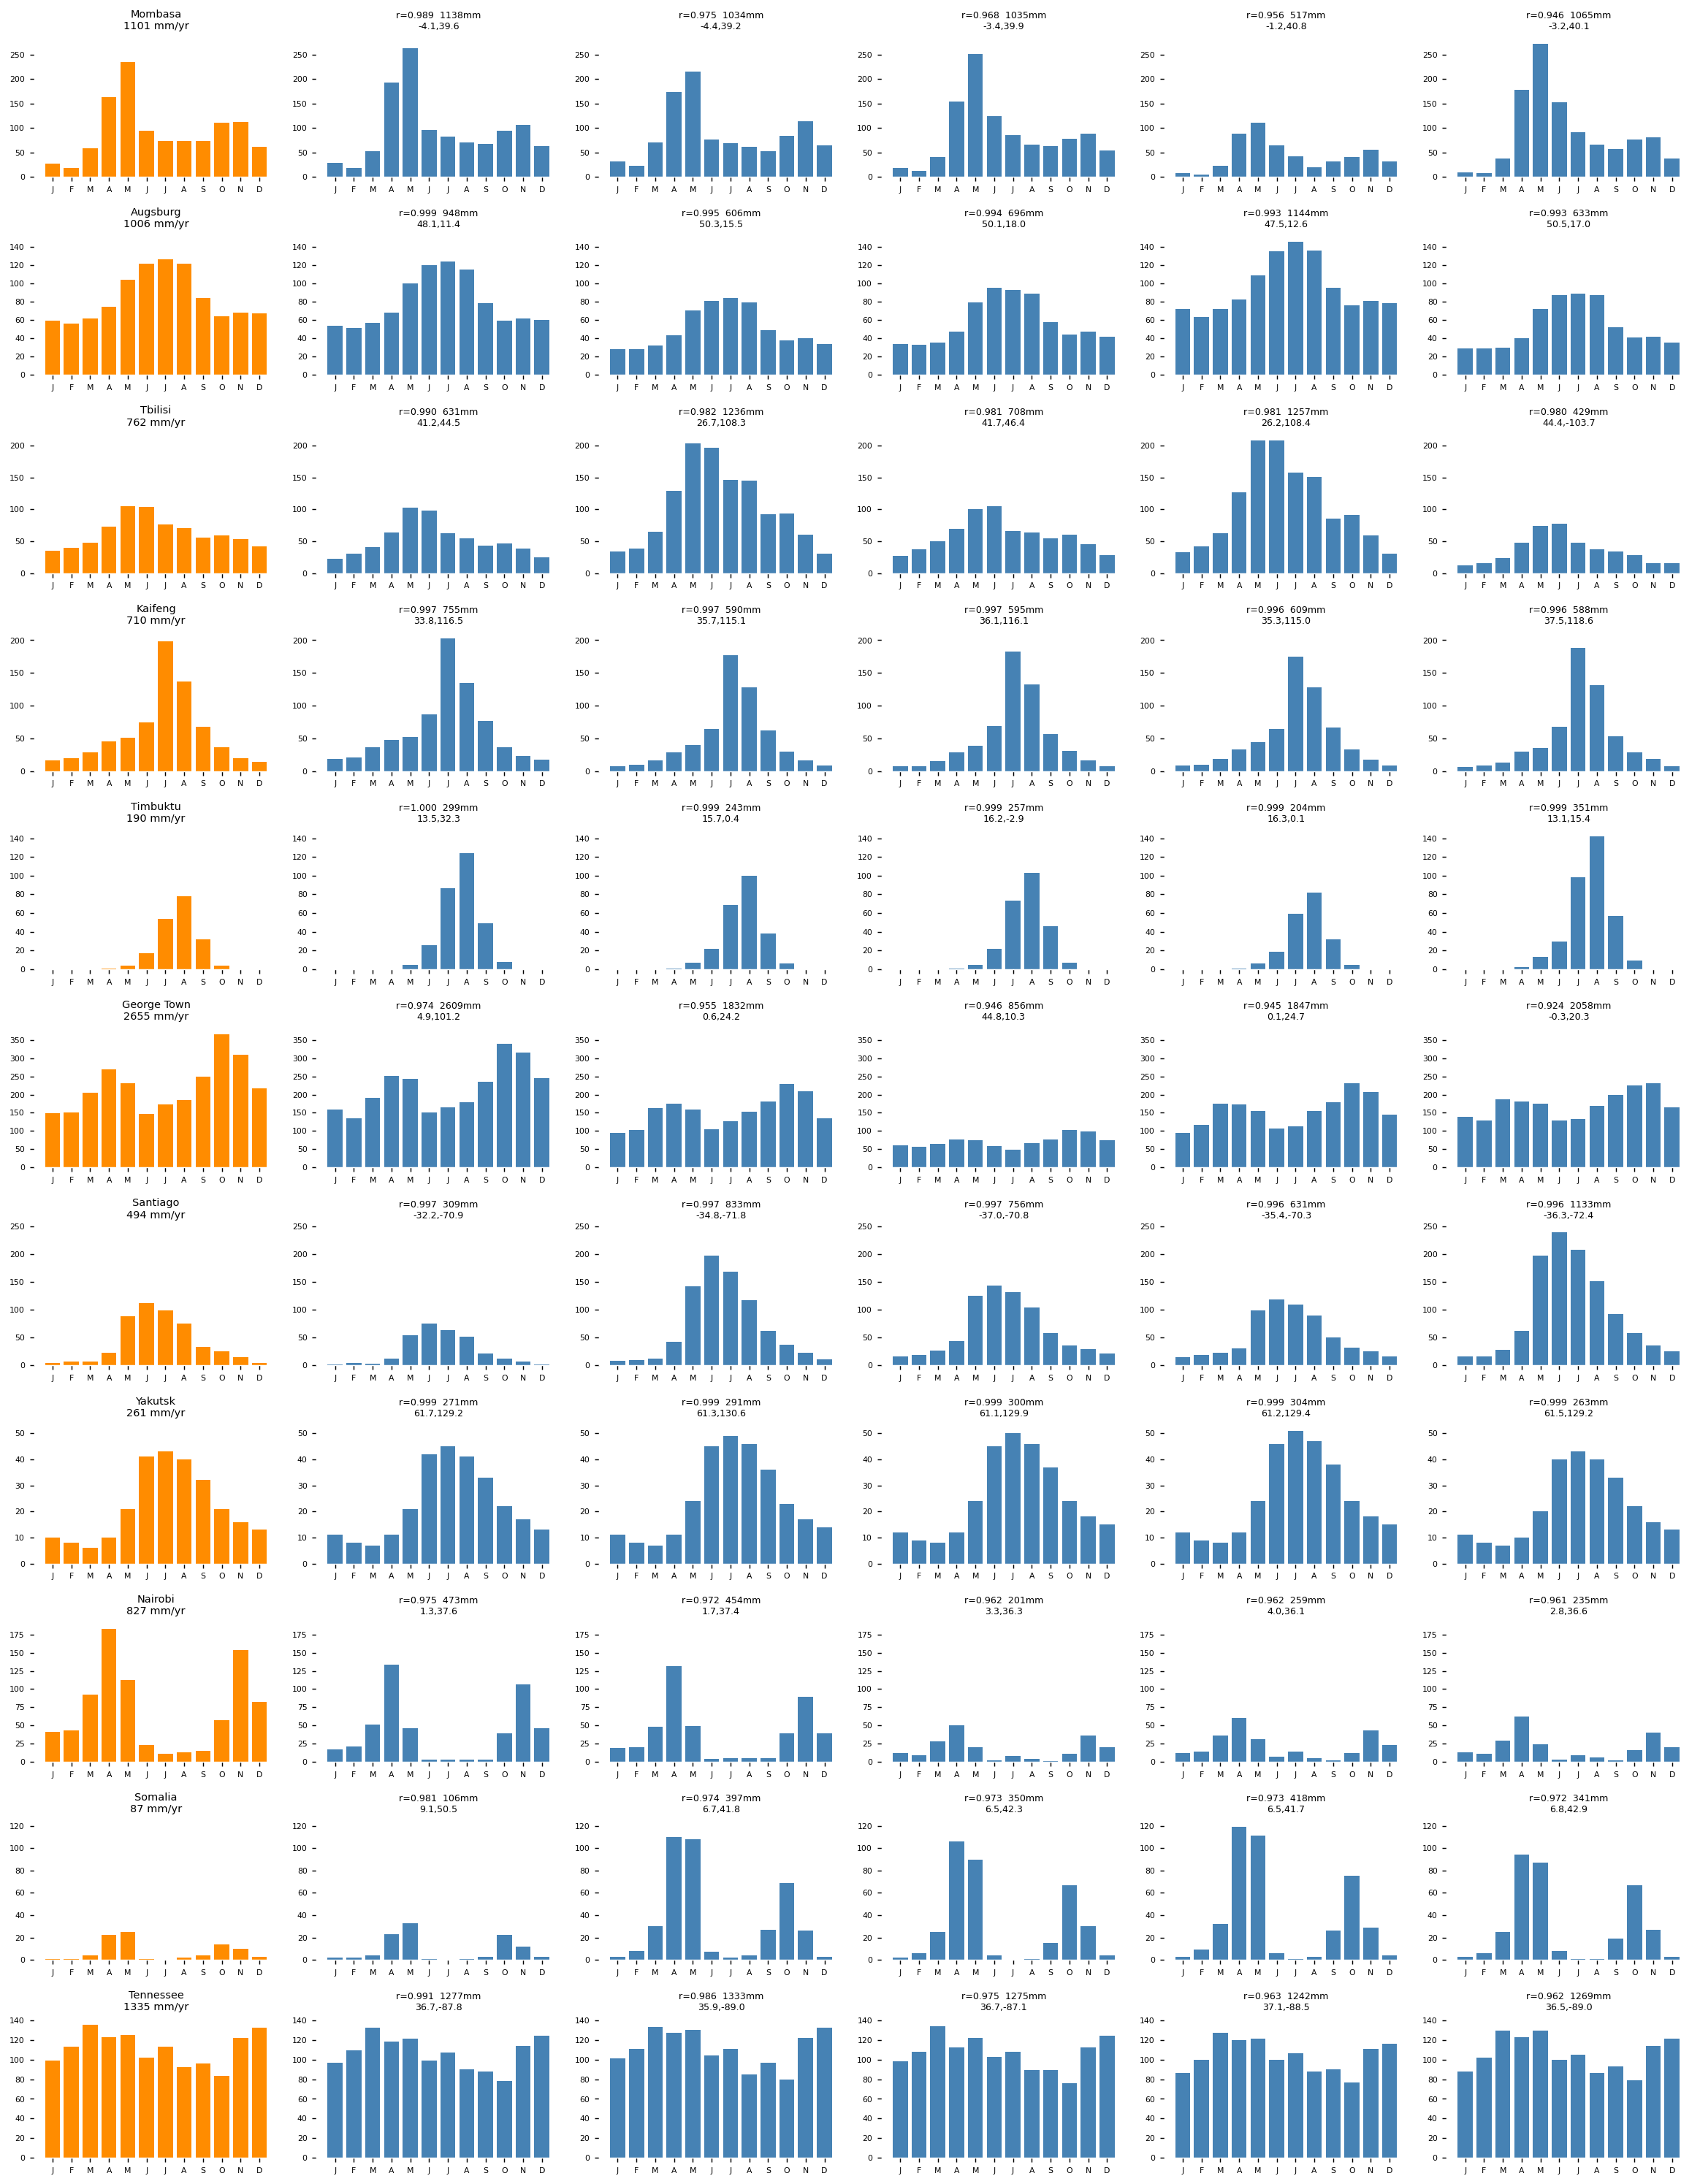

In [12]:
# Cell 10 — Part B figure: draw every result
# "Draw the compared dimension before theorising about the measure" -- this rule has paid off
# four times (WO2a validation, George Town, the peak-count detour, WO6a's R_dbl profiles) and
# been skipped once (the phase lens went four design rounds without it).
# Numeric x-positions with letters applied as tick labels: bar() with repeated string labels
# collapses same-letter months onto one position (the WO6a Cell 12 bug).
DRAW_N = 5

print("drawing probe neighbour profiles...")
names = list(probes['probe'])
fig, axes = plt.subplots(len(names), DRAW_N + 1, figsize=(3.0 * (DRAW_N + 1), 2.1 * len(names)))
fig.patch.set_facecolor('white')

for r, name in enumerate(names):
    q = _pq.loc[name]
    c = probe_corr[name]
    order = np.argsort(-c)[:DRAW_N]
    qi = int(q['idx'])
    ymax = max(PRE[qi].max(), PRE[order].max()) * 1.05   # shared scale per row

    ax = axes[r, 0]; ax.set_facecolor('white')
    ax.bar(month_x, PRE[qi], color='darkorange')
    ax.set_ylim(0, ymax); ax.set_xticks(month_x); ax.set_xticklabels(MONTH_LETTERS, fontsize=6)
    ax.set_title(f"{name}\n{q['pre_total']:.0f} mm/yr", color='black', fontsize=8)
    ax.tick_params(colors='black', labelsize=6)

    for k, j in enumerate(order):
        ax = axes[r, k + 1]; ax.set_facecolor('white')
        ax.bar(month_x, PRE[j], color='steelblue')
        ax.set_ylim(0, ymax); ax.set_xticks(month_x); ax.set_xticklabels(MONTH_LETTERS, fontsize=6)
        ax.set_title(f"r={c[j]:.3f}  {df.loc[j,'pre_total']:.0f}mm\n"
                     f"{df.loc[j,'lat']:.1f},{df.loc[j,'lon']:.1f}", color='black', fontsize=7)
        ax.tick_params(colors='black', labelsize=6)

fig.tight_layout()
out_path = OUT / 'wo6b_partB_probe_neighbours.png'
fig.savefig(out_path, facecolor='white', dpi=130, bbox_inches='tight')
plt.close(fig)
display(IPImage(str(out_path)))

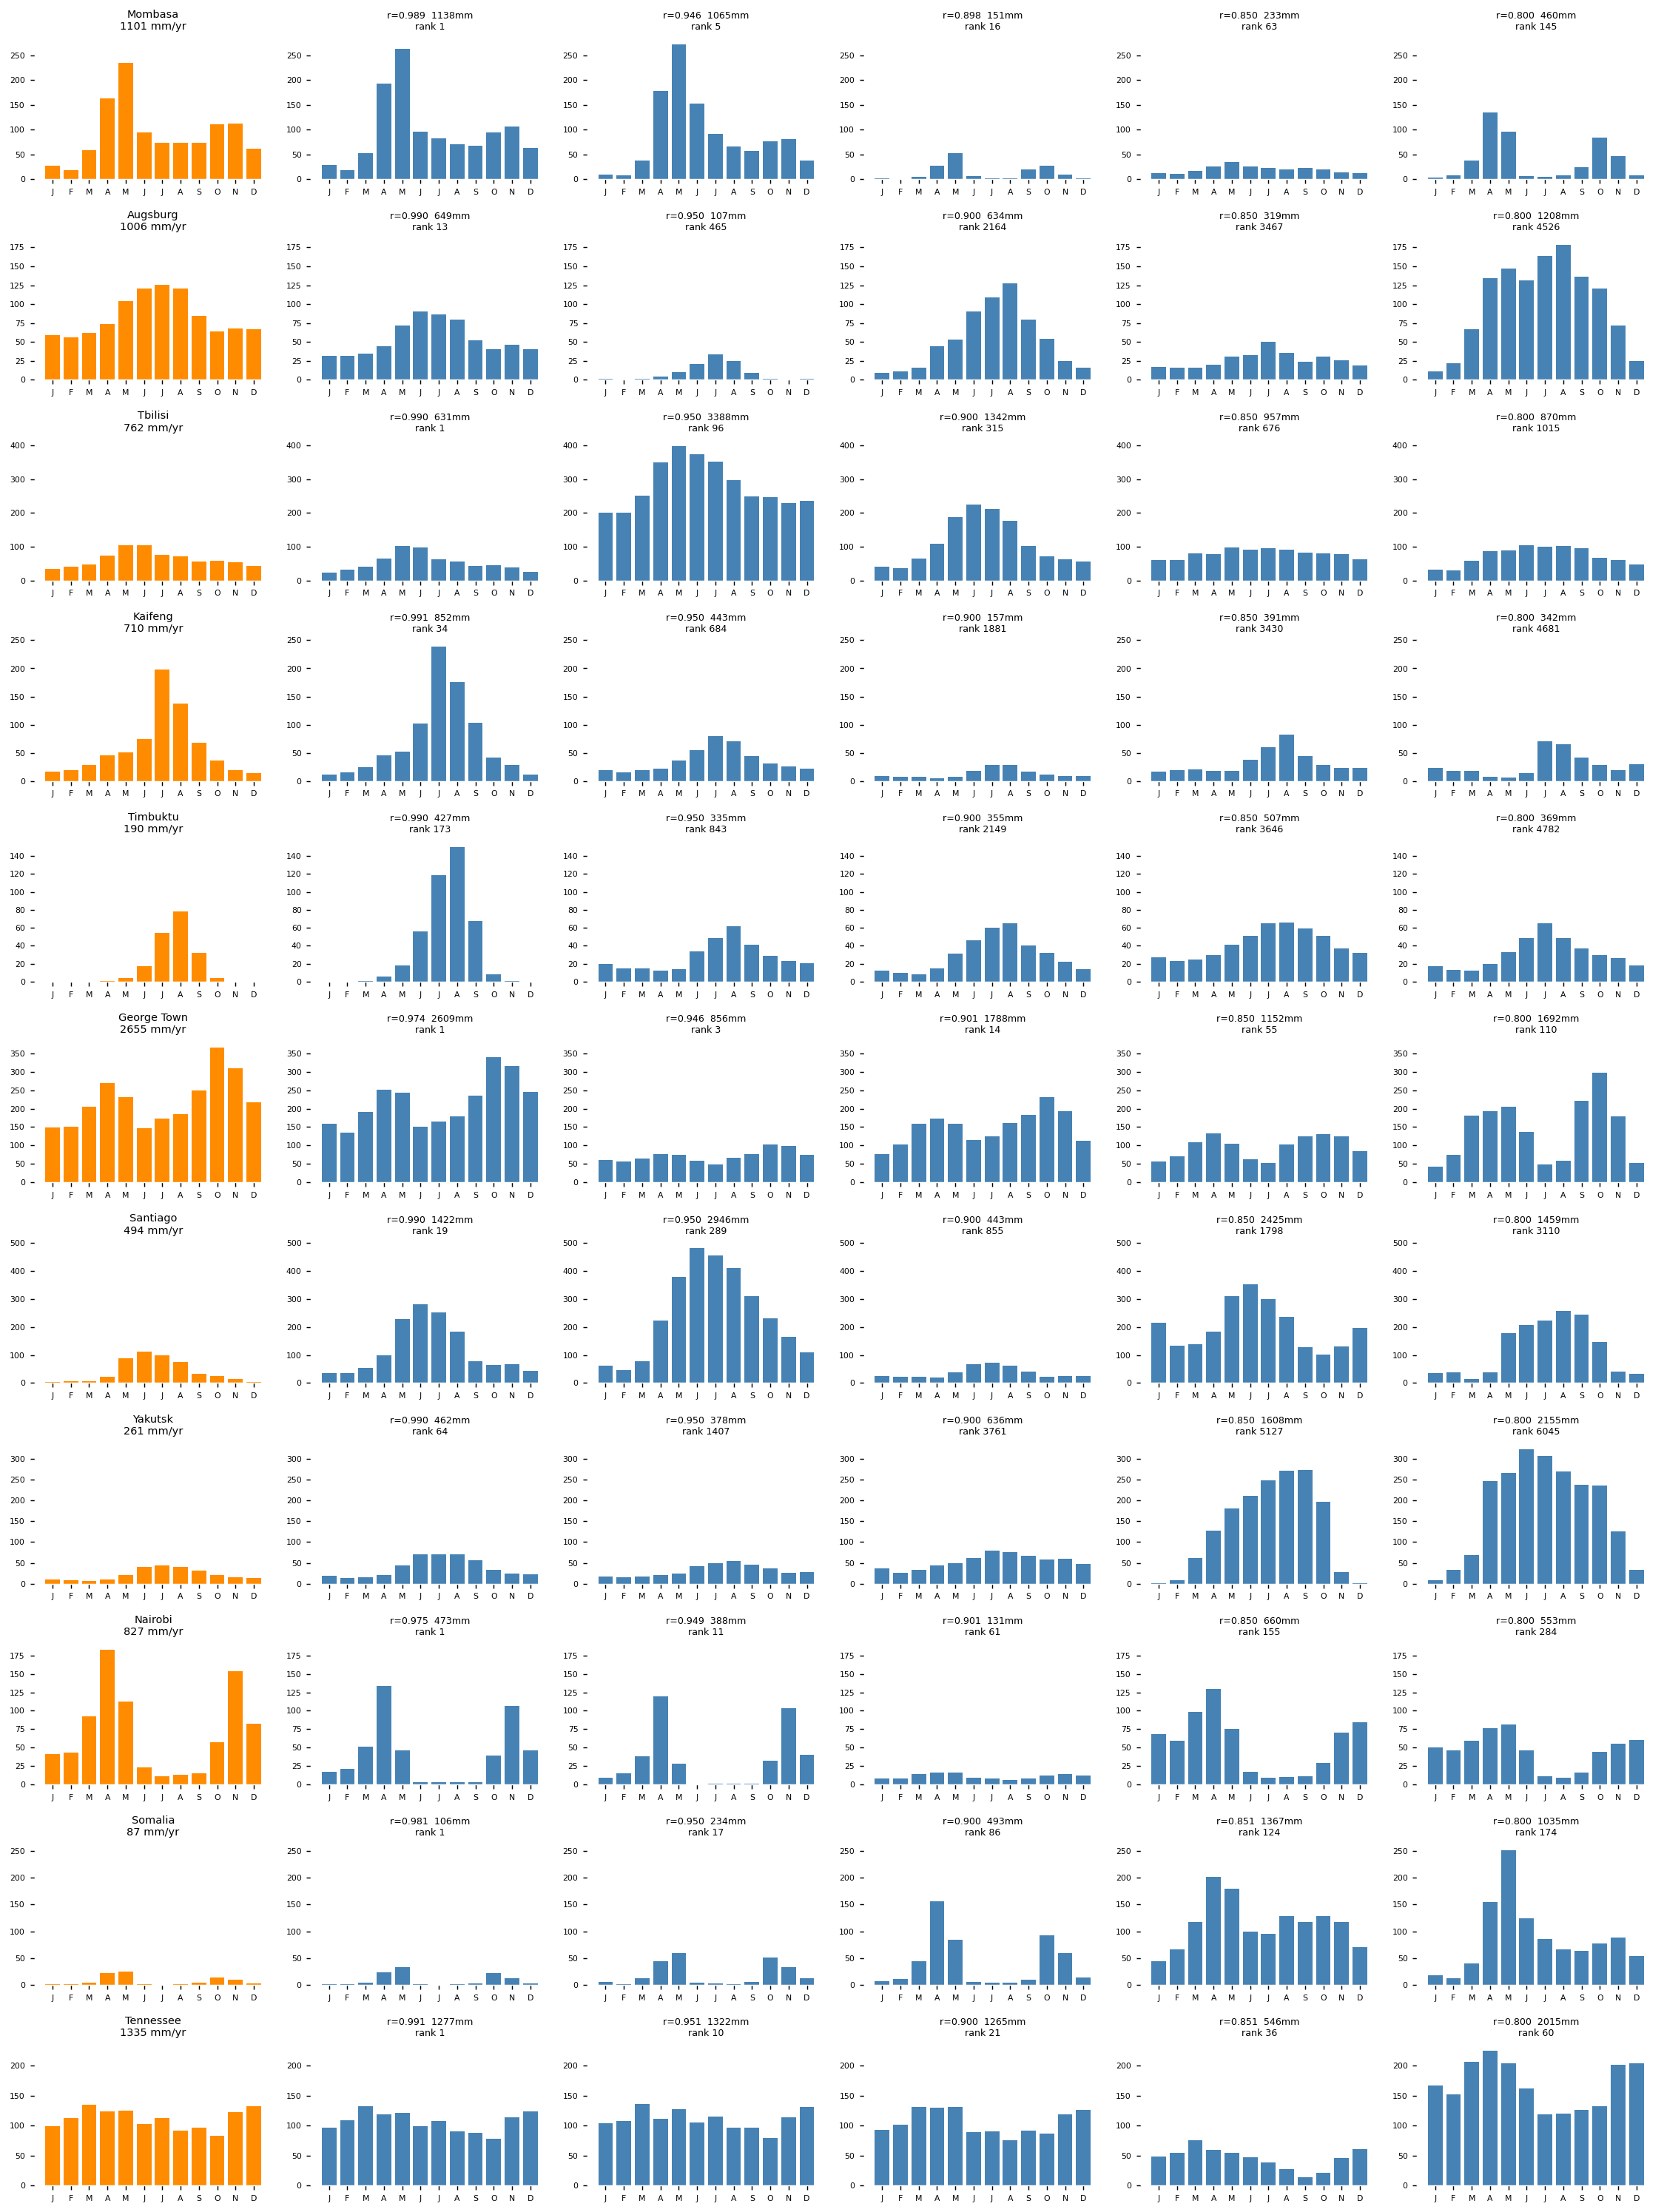

In [13]:
# Cell 10b — Break test: is a given correlation VALUE comparable across queries?
# (numbered 10b deliberately -- a whole number would renumber Cells 11-18, which we have
# already been discussing by number)
#
# Cell 10 drew ranks 1-5, and Cell 7 showed ranks 1-10 are near-ties for every probe, so that
# figure is a flattering slice by construction. Two things it cannot tell us:
#
#   1. Do matches deeper in the ranking still look right, or is the quality a top-of-list
#      artifact?
#   2. Part D applies ONE global correlation cut to every query. That is only sound if a given
#      correlation value means the same thing regardless of which basin is asking. If r=0.90
#      looks convincing for Timbuktu and poor for Nairobi, a single declared cut is unsound and
#      the cut has to be per-query -- which would badly damage the CEM framing.
#
# So: for each probe, find the neighbour whose correlation is CLOSEST to each target value,
# draw it, and report the rank it happens to sit at. One figure answers both questions.

TARGETS = [0.99, 0.95, 0.90, 0.85, 0.80]

rank_rows = []
picks = {}
for name in probes['probe']:
    c = probe_corr[name]
    finite = np.isfinite(c)
    order = np.argsort(-c)
    rank_of = np.empty(len(c), dtype=int)
    rank_of[order] = np.arange(1, len(c) + 1)
    sel, rec = [], {'probe': name}
    for tgt in TARGETS:
        j = int(np.argmin(np.where(finite, np.abs(c - tgt), np.inf)))
        sel.append(j)
        rec[f'rank@{tgt}'] = int(rank_of[j])
    picks[name] = sel
    rank_rows.append(rec)

print("\n".join([
    "rank at which each probe reaches a given correlation value:",
    pd.DataFrame(rank_rows).to_string(index=False),
    "",
    "Wildly different ranks for the same correlation is EXPECTED -- that is Cell 7's",
    "density finding restated. The question the FIGURE answers is whether they LOOK",
    "equally similar.",
    "",
    "drawing iso-correlation comparison...",
]))
names = list(probes['probe'])
fig, axes = plt.subplots(len(names), len(TARGETS) + 1,
                         figsize=(2.9 * (len(TARGETS) + 1), 2.1 * len(names)))
fig.patch.set_facecolor('white')

for r, name in enumerate(names):
    q = _pq.loc[name]
    c = probe_corr[name]
    qi = int(q['idx'])
    sel = picks[name]
    ymax = max(PRE[qi].max(), PRE[sel].max()) * 1.05

    ax = axes[r, 0]; ax.set_facecolor('white')
    ax.bar(month_x, PRE[qi], color='darkorange')
    ax.set_ylim(0, ymax); ax.set_xticks(month_x); ax.set_xticklabels(MONTH_LETTERS, fontsize=6)
    ax.set_title(f"{name}\n{q['pre_total']:.0f} mm/yr", color='black', fontsize=8)
    ax.tick_params(colors='black', labelsize=6)

    for k, j in enumerate(sel):
        ax = axes[r, k + 1]; ax.set_facecolor('white')
        ax.bar(month_x, PRE[j], color='steelblue')
        ax.set_ylim(0, ymax); ax.set_xticks(month_x); ax.set_xticklabels(MONTH_LETTERS, fontsize=6)
        ax.set_title(f"r={c[j]:.3f}  {df.loc[j,'pre_total']:.0f}mm\n"
                     f"rank {rank_rows[r][f'rank@{TARGETS[k]}']}", color='black', fontsize=7)
        ax.tick_params(colors='black', labelsize=6)

fig.tight_layout()
out_path = OUT / 'wo6b_partB_iso_correlation.png'
fig.savefig(out_path, facecolor='white', dpi=130, bbox_inches='tight')
plt.close(fig)
display(IPImage(str(out_path)))

In [14]:
# Cell 11 — Part B: is modality emergent? (the proviso, tested directly)
# WO6a's peak-count (frac=0.20 of own range, 10mm absolute floor) is used here ONLY as an
# independent label to test whether correlation separates the classes on its own. It is NOT
# part of the correlation measure -- that is the whole point.

def _walk_to_col(V, s, step):
    N = V.shape[0]; floor = np.full(N, np.inf); active = np.ones(N, dtype=bool)
    vs = V[:, s]; i = s
    for _ in range(12):
        i = (i + step) % 12
        cur = V[:, i]
        active &= ~(cur > vs)
        if not active.any(): break
        floor = np.where(active, np.minimum(floor, cur), floor)
    return floor

def circular_peak_count(V, frac=0.20, abs_floor_mm=10.0):
    rng_ = V.max(axis=1) - V.min(axis=1)
    thresh = np.maximum(frac * rng_, abs_floor_mm)
    count = np.zeros(V.shape[0], dtype=int)
    for s in range(12):
        left, right = V[:, (s - 1) % 12], V[:, (s + 1) % 12]
        vs = V[:, s]
        cand = (vs >= left) & (vs >= right) & ((vs > left) | (vs > right))
        prom = vs - np.maximum(_walk_to_col(V, s, -1), _walk_to_col(V, s, +1))
        count += (cand & (prom >= thresh)).astype(int)
    return count

peaks = circular_peak_count(PRE)
df['peak_count'] = peaks

rows = []
for _, p in probes.iterrows():
    c = probe_corr[p['probe']]
    elig = np.isfinite(c)
    qpk = peaks[p['idx']]
    same = elig & (peaks == qpk)
    diff = elig & (peaks != qpk)
    top50 = np.argsort(-c)[:50]
    rows.append({
        'probe': p['probe'], 'query_peaks': int(qpk),
        'class_prevalence_pct': round(100 * float(same.sum() / elig.sum()), 1),
        'mean_corr_same_class': round(float(c[same].mean()), 4),
        'mean_corr_diff_class': round(float(c[diff].mean()), 4),
        'separation': round(float(c[same].mean() - c[diff].mean()), 4),
        'top50_same_class_pct': round(100 * float((peaks[top50] == qpk).mean()), 1),
    })

emergent = pd.DataFrame(rows)
print(emergent.to_string(index=False))
print("\nCompare top50_same_class_pct against class_prevalence_pct -- the baseline you would get")
print("by chance. Enrichment well above prevalence, with modality nowhere in the metric, means")
print("modality is emergent from shape and WO6a Part A's threshold problem is dissolved, not solved.")

      probe  query_peaks  class_prevalence_pct  mean_corr_same_class  mean_corr_diff_class  separation  top50_same_class_pct
    Mombasa            1                  80.1               -0.0305                0.1579     -0.1884                  18.0
   Augsburg            1                  80.1                0.2592                0.0371      0.2221                  98.0
    Tbilisi            1                  80.1                0.1199                0.0995      0.0204                  96.0
    Kaifeng            1                  80.1                0.2816               -0.0067      0.2883                 100.0
   Timbuktu            1                  80.1                0.2876               -0.0277      0.3153                 100.0
George Town            2                  17.4                0.1207               -0.0805      0.2013                  92.0
   Santiago            1                  80.1                0.2208                0.0470      0.1737                  98.0


## Part C — Knoben ΔE as an independent modality measure

Implemented from Knoben, Woods & Freer (2019) §3, which builds on Berghuijs & Woods (2016) eqs 1–4. The Knoben PDF's math glyphs are corrupted by font encoding; the equations below are reproduced from B&W, which states them cleanly and is the cited source.

```
P_sim(t) = max(0, P̄ · [1 + C_r(δ) + δ · sin(2π(t − s)/τ)])
C_r(δ)   = −0.001·δ⁴ + 0.026·δ³ − 0.245·δ² + 0.2432·δ − 0.038     (applied only when δ > 1)
E        = (1/12) · Σ_months |P_sim − P_obs| / P̄
ΔE       = E(τ=12) − E(τ=6)          positive ⇒ bimodal
```

`P̄` is taken directly from the data, not fitted, so both models have exactly two free parameters (`δ`, `s`). That equal-degrees-of-freedom condition is what makes the two error values comparable — and it is *why* the bimodal curve is forced to equal-amplitude peaks. No threshold anywhere in the modality decision, which is precisely the hole WO6a Part A fell into.

**What the paper already tells us about our probes — read before running.** WO6b treats Mombasa's asymmetry as an open test. The paper does not leave it open. On regimes where "one wet season has distinctly higher rainfall than the other" it states the method "shows no clear improvement of bimodal sine curves over unimodal sines... because our very simple bimodal sine curves are unable to replicate this specific behaviour," and that in its own East Africa transect "the asymmetry of the wet seasons causes the unimodal sine to be more accurate than the bimodal sine." So:

- **Mombasa** (235 mm May vs 110 mm Nov) should come out unimodal — a documented limitation, not a surprise.
- **George Town** should *also* come out unimodal, **contradicting WO6b's prediction**. The paper names "the Malaysian peninsula and several Indonesian islands" among exactly these asymmetric failure cases. WO6b's reasoning (high baseline is factored out because seasonality is a fraction of the mean) is correct as far as it goes, but it is peak *asymmetry*, not baseline, that sinks this case.
- **Timbuktu** should come out unimodal, and WO6b's reasoning holds — but it sits in the paper's own declared high-error zone (P < 240 mm/yr; Timbuktu is 189). `THRESH_ARID` at 100 mm does not screen it out. Treat its ΔE as low-confidence either way.

So Part C runs as **confirmation of a documented limitation**, not as an open test. Both error values are reported alongside ΔE, because the paper's own diagnostic for these cases is that *both* curves fit badly — a small ΔE on top of two large errors means neither model describes the regime, which is a different statement from "unimodal."

In [19]:
# Cell 12 — Knoben implementation + validation on synthetic curves
# Validate before trusting, per WO6a Cell 7: build curves whose modality is known by
# construction and confirm the verdict -- including the paper's stated failure case.
# All output in ONE print (successive print() calls overwrite in the PyCharm console).

_t = np.arange(12)

# ---------------------------------------------------------------------------
# Period-agnostic seasonality amplitude, computed corpus-wide here so Cells 13/16/18 can use it.
#
# WHY NOT delta_P: delta from the tau=12 fit is only a property of the basin when the tau=12
# MODEL FITS. Cell 14 showed George Town's tau=12 curve is a near-flat line at ~200-240 against
# data running 149-365 -- the 12-month sine cannot track a bimodal curve, so it collapses and
# its delta (0.088) measures the failed model, not the basin. Tennessee, genuinely flat, gets
# delta 0.140. The measure ranks them BACKWARDS. The first-harmonic ratio (rel_amp) has the
# identical flaw, since the first harmonic of a bimodal curve is also small.
#
# CV assumes no period at all: George Town ~0.30, Tennessee ~0.14 -- right order, 2x apart.
CV_ALL = PRE.std(axis=1) / np.where(PRE.mean(axis=1) > 0, PRE.mean(axis=1), np.nan)
df['cv'] = CV_ALL

def _cr(delta):
    """B&W eq 4 correction factor; zero below delta=1, where no truncation occurs."""
    d = float(delta)
    poly = -0.001*d**4 + 0.026*d**3 - 0.245*d**2 + 0.2432*d - 0.038
    return poly if d > 1 else 0.0

def knoben_sim(pbar, delta, s, tau):
    return np.maximum(0.0, pbar * (1.0 + _cr(delta) + delta * np.sin(2*np.pi*(_t - s)/tau)))

def knoben_fit(p_obs, tau):
    """Fit (delta, s) minimising Knoben eq 5 / B&W's objective. Returns (E, delta, s)."""
    pbar = p_obs.mean()
    if pbar <= 0:
        return np.nan, np.nan, np.nan
    def obj(par):
        delta, s = par
        if delta < 0:
            return 1e6
        return np.abs(knoben_sim(pbar, delta, s, tau) - p_obs).mean() / pbar
    best = (np.inf, np.nan, np.nan)
    for s0 in np.linspace(0, tau, 6, endpoint=False):
        for d0 in (0.3, 0.8, 1.5, 3.0):
            r = minimize(obj, x0=[d0, s0], method='Nelder-Mead',
                         options={'xatol': 1e-6, 'fatol': 1e-8, 'maxiter': 2000})
            if r.fun < best[0]:
                best = (float(r.fun), float(r.x[0]), float(r.x[1] % tau))
    return best

# Three-way verdict. Two states the raw sign of dE cannot express:
#
#   ASEASONAL    -- there is no cycle to have a modality. Detected on CV, which is
#                   period-agnostic, NOT on delta (see the note above). Cell 14 showed
#                   Tennessee with BOTH curves fitting well (0.09 / 0.11) as flat horizontal
#                   lines and dE = -0.016: the earlier delta-based rule missed it entirely.
#   UNDETERMINED -- both curves fit badly and dE is negligible. This is what Knoben actually
#                   reports for strongly asymmetric bimodal regimes ("no clear improvement of
#                   bimodal sine curves over unimodal sines") -- the method abstains, it does
#                   not flip to unimodal, which is what the earlier Part C markdown claimed.
#
# CV_FLAT is a DECLARED threshold, and unavoidably so -- "how flat is flat" is a matter of
# degree. It is better behaved than WO6a's prominence floor on two counts: dimensionless, so it
# transfers across climates, and applied to one interpretable quantity rather than a composite
# that lets terms compensate. 0.20 sits between Tennessee (0.144) and George Town (0.296);
# Cell 18 reports the corpus distribution so it can be moved on evidence.
CV_FLAT      = 0.20
POOR_E       = 0.25    # both errors above this => neither model describes the regime
NEGLIGIBLE_D = 0.02    # |dE| below this => no meaningful preference between the models

def knoben_verdict(p_obs):
    e12, d12, s12 = knoben_fit(p_obs, 12.0)
    e6,  d6,  s6  = knoben_fit(p_obs, 6.0)
    dE = e12 - e6
    m = p_obs.mean()
    cv = float(p_obs.std() / m) if m > 0 else np.nan
    if cv < CV_FLAT:
        v = 'ASEASONAL'
    elif min(e12, e6) > POOR_E and abs(dE) < NEGLIGIBLE_D:
        v = 'UNDETERMINED'
    elif dE > 0:
        v = 'BIMODAL'
    else:
        v = 'unimodal'
    return {'E_tau12': e12, 'E_tau6': e6, 'dE': dE, 'verdict': v, 'cv': cv,
            'delta_12': d12, 's_12': s12, 'delta_6': d6, 's_6': s6}

knoben_delta_e = knoben_verdict          # name kept for downstream cells

# --- synthetic validation -------------------------------------------------
def _mk(peaks, base=10.0, width=1.2):
    """Sum of gaussian bumps on a circle: peaks = [(month, height), ...]."""
    v = np.full(12, float(base))
    for m_, h in peaks:
        d = np.minimum(np.abs(_t - m_), 12 - np.abs(_t - m_))
        v = v + h * np.exp(-0.5 * (d / width) ** 2)
    return v

cases = {
    'unimodal sharp (monsoon-like)':      _mk([(7, 200)], base=2),
    'unimodal broad':                     _mk([(7, 60)],  base=40, width=2.2),
    'bimodal symmetric':                  _mk([(3, 100), (9, 100)], base=20),
    'bimodal mildly asym (1.5:1)':        _mk([(3, 150), (9, 100)], base=20),
    'bimodal asymmetric (2:1)':           _mk([(3, 200), (9, 100)], base=20),
    'bimodal strongly asym (4:1)':        _mk([(3, 200), (9, 50)],  base=20),
    'aseasonal flat':                     _mk([], base=80),
    'aseasonal + noise':                  _mk([(2, 12), (6, 9), (10, 11)], base=100, width=1.0),
    'weakly seasonal (Tennessee-like)':   _mk([(2, 20), (11, 18)], base=100, width=2.0),
}
out = ["synthetic validation -- known modality by construction", ""]
for label, v in cases.items():
    r = knoben_verdict(v)
    out.append(f"  {label:34s} E12={r['E_tau12']:.3f} E6={r['E_tau6']:.3f} "
               f"dE={r['dE']:+.3f}  cv={r['cv']:.3f}  d12={r['delta_12']:6.2f}  -> {r['verdict']}")
out += ["",
        "Expected: both unimodal cases -> unimodal (the sharp one is the Timbuktu shape that",
        "fools R_dbl, so a large negative dE there is the key check). Symmetric bimodal ->",
        "BIMODAL. As asymmetry grows, dE collapses toward zero with BOTH errors large -- the",
        "paper's 'no clear improvement', i.e. the method abstains rather than misclassifies.",
        "Both flat cases -> ASEASONAL, now caught on CV rather than delta.",
        "",
        "Watch d12 against cv: for the bimodal rows d12 is small NOT because the basin is flat",
        "but because the 12-month model failed. That divergence is the whole reason Part D's",
        "amplitude condition moves to CV."]
print("\n".join(out))


synthetic validation -- known modality by construction

  unimodal sharp (monsoon-like)      E12=0.111 E6=0.928 dE=-0.817  cv=1.298  d12=  5.71  -> unimodal
  unimodal broad                     E12=0.036 E6=0.265 dE=-0.229  cv=0.304  d12=  0.42  -> unimodal
  bimodal symmetric                  E12=0.432 E6=0.041 dE=+0.392  cv=0.461  d12=  0.32  -> BIMODAL
  bimodal mildly asym (1.5:1)        E12=0.459 E6=0.146 dE=+0.312  cv=0.521  d12=  0.46  -> BIMODAL
  bimodal asymmetric (2:1)           E12=0.478 E6=0.254 dE=+0.224  cv=0.597  d12=  0.30  -> BIMODAL
  bimodal strongly asym (4:1)        E12=0.443 E6=0.439 dE=+0.004  cv=0.728  d12=  1.15  -> UNDETERMINED
  aseasonal flat                     E12=0.000 E6=0.000 dE=+0.000  cv=0.000  d12=  0.00  -> ASEASONAL
  aseasonal + noise                  E12=0.020 E6=0.021 dE=-0.001  cv=0.027  d12=  0.01  -> ASEASONAL
  weakly seasonal (Tennessee-like)   E12=0.001 E6=0.073 dE=-0.072  cv=0.080  d12=  0.11  -> ASEASONAL

Expected: both unimodal cases 

In [20]:
# Cell 13 — Knoben verdict + Berghuijs & Woods indices for the probes
# One print for the whole cell (PyCharm console overwrites successive prints).
#
# delta_P, s_P and therefore s_d are properties of the tau=12 FIT, so they are only
# interpretable when that fit is any good. Cell 14 made this concrete: George Town's tau=12
# curve is a flat line, so its delta (0.088) and phase (4.75) describe a failed model, not the
# basin -- and s_d inherits the error. Those columns are now blanked when E_tau12 > POOR_E,
# rather than printed as though they were measurements. `cv` is shown alongside as the
# period-agnostic amplitude that stays valid regardless of which model fits.

def temp_harmonic(t_obs):
    """First-harmonic amplitude and phase of the temperature cycle. Returns
    (delta_T degC, s_T in months), with s_T the phase of sin(2*pi*(t - s)/12).
    Temperature is genuinely single-cycle everywhere, so this one is safe."""
    a = (t_obs * np.cos(2*np.pi*_t/12)).mean() * 2
    b = (t_obs * np.sin(2*np.pi*_t/12)).mean() * 2
    return float(np.hypot(a, b)), float((np.arctan2(-a, b) * 12 / (2*np.pi)) % 12)

def phase_diff_months(s_p, s_t):
    """B&W eq 5: signed P-T phase difference wrapped to [-6, +6] months."""
    d = (s_p - s_t) % 12
    return d - 12 if d > 6 else d

rows = []
for _, p in probes.iterrows():
    i = int(p['idx'])
    r = knoben_verdict(PRE[i])
    dT, sT = temp_harmonic(TMP[i])
    ok = r['E_tau12'] <= POOR_E                      # is the tau=12 fit usable at all?
    rows.append({
        'probe': p['probe'],
        'pre_total': round(float(p['pre_total']), 0),
        'peaks_wo6a': int(df.loc[i, 'peak_count']),
        'cv': round(r['cv'], 3),
        'E_tau12': round(r['E_tau12'], 3),
        'E_tau6': round(r['E_tau6'], 3),
        'dE': round(r['dE'], 3),
        'knoben': r['verdict'],
        'both_poor': bool(min(r['E_tau12'], r['E_tau6']) > POOR_E),
        'fit12_ok': bool(ok),
        'delta_P': round(r['delta_12'], 3) if ok else None,
        's_P':     round(r['s_12'], 2)     if ok else None,
        'delta_T': round(dT, 2),
        's_T':     round(sT, 2),
        's_d':     round(phase_diff_months(r['s_12'], sT), 2) if ok else None,
    })

knoben_probe = pd.DataFrame(rows)
print("\n".join([
    knoben_probe.to_string(index=False),
    "",
    "fit12_ok=False => delta_P / s_P / s_d are blank because the tau=12 model does not describe",
    "the basin; a number there would look like a measurement and would not be one.",
    "both_poor=True => neither model describes the regime (Knoben's own diagnostic for",
    "asymmetric bimodal). Distinct from 'unimodal'.",
    "Knoben's global reference for E(tau=12): mean 0.18, median 0.15, sd 0.10.",
    "",
    "cv is the period-agnostic seasonal amplitude and stays valid whichever model wins --",
    "compare it against delta_P wherever both are present.",
    "s_d near 0 => rain falls with warmth; near +/-6 => rain against warmth (Mediterranean).",
]))


      probe  pre_total  peaks_wo6a    cv  E_tau12  E_tau6     dE    knoben  both_poor  fit12_ok  delta_P   s_P  delta_T  s_T   s_d
    Mombasa     1101.0           1 0.621    0.460   0.325  0.134   BIMODAL       True     False      NaN   NaN     1.87 9.75   NaN
   Augsburg     1006.0           1 0.305    0.102   0.252 -0.150  unimodal      False      True    0.447  3.03     8.93 3.18 -0.15
    Tbilisi      762.0           1 0.350    0.144   0.273 -0.129  unimodal      False      True    0.431  2.52    10.79 3.27 -0.75
    Kaifeng      710.0           1 0.902    0.381   0.617 -0.236  unimodal       True     False      NaN   NaN    13.50 3.07   NaN
   Timbuktu      190.0           1 1.562    0.145   0.989 -0.845  unimodal      False      True   11.457  3.61     5.10 2.57  1.04
George Town     2655.0           2 0.296    0.230   0.131  0.099   BIMODAL      False      True    0.088  4.75     0.50 1.06  3.69
   Santiago      494.0           1 0.945    0.228   0.753 -0.525  unimodal      Fal

In [ ]:
# Cell 14 — Part C figure: observed profile vs both fitted curves, per probe
# Legend text coloured explicitly -- PyCharm defaults it to white (invisible on white).
print("drawing Knoben fits...")
names = list(probes['probe'])
ncol = 4
nrow = int(np.ceil(len(names) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.6 * ncol, 3.0 * nrow))
fig.patch.set_facecolor('white')

for k, name in enumerate(names):
    ax = axes.flat[k]; ax.set_facecolor('white')
    i = int(_pq.loc[name, 'idx'])
    obs = PRE[i]; pbar = obs.mean()
    r = knoben_delta_e(obs)
    ax.bar(month_x, obs, color='lightsteelblue')
    ax.plot(month_x, knoben_sim(pbar, r['delta_12'], r['s_12'], 12.0), color='navy',
            linewidth=1.8, label=f"tau=12  E={r['E_tau12']:.2f}")
    ax.plot(month_x, knoben_sim(pbar, r['delta_6'], r['s_6'], 6.0), color='firebrick',
            linewidth=1.8, label=f"tau=6   E={r['E_tau6']:.2f}")
    ax.set_xticks(month_x); ax.set_xticklabels(MONTH_LETTERS, fontsize=7)
    # verdict from Cell 12's three-way knoben_verdict (ASEASONAL / UNDETERMINED / ...),
    # not a local dE>0 test -- the plot title must agree with Cell 13's table.
    ax.set_title(f"{name}   dE={r['dE']:+.3f}  cv={r['cv']:.2f}  -> {r['verdict']}",
                 color='black', fontsize=9)
    ax.tick_params(colors='black', labelsize=7)
    leg = ax.legend(fontsize=7)
    for txt in leg.get_texts():
        txt.set_color('black')
for ax in axes.flat[len(names):]:
    ax.axis('off')

fig.tight_layout()
out_path = OUT / 'wo6b_partC_knoben_fits.png'
fig.savefig(out_path, facecolor='white', dpi=130, bbox_inches='tight')
plt.close(fig)
display(IPImage(str(out_path)))

## Part D — The conjunctive instrument, rebuilt on shape correlation

Every condition must be satisfied; none can compensate for another. WO6a established that such a rule does not starve (~111 matches at L06 at the tightest tolerance; k=4 does not collapse). Per-variable units, because WO6a Part B forced one rule across all variables and found each fails in mirror image — the transform that makes a band meaningful differs by variable.

| condition | rule | why this unit |
|---|---|---|
| shape | profile correlation ≥ `c` | parameter-free, scale-free, no harmonic assumption |
| magnitude | annual total within a ratio band (×/÷ `m`) | a band on log; immune to the right-skew that made both WO6a rules misbehave at the wet end |
| amplitude | `cv` within ±`a` — **provisional, on probation** | see below |
| temperature level | mean within ±`dt` °C | physically interpretable |
| temperature range | seasonal range within ±`dr` °C | physically interpretable |

**The amplitude condition is unresolved and this cell is the test of whether to keep it.** Part A promised a scale-free amplitude term. Two candidates were tried and *both* are broken as graded bands:

- `delta_P` (τ=12 fit amplitude) **collapses on bimodal profiles** — the 12-month sine cannot track two peaks, so its amplitude reflects a failed model, not the basin. George Town (genuinely bimodal) scores 0.088 against flat Tennessee's 0.140 — backwards. Shown in Cell 14's fitted curves.
- `cv` (sd/mean) **explodes on dry-season zeros** — a sharp monsoon on a near-zero baseline has huge sd/mean, so Timbuktu (1.56) and Somalia (1.14) top the ranking on aridity, not seasonality.

`cv` is retained here **only** because it is the lesser evil and because Cell 16 reports each condition's standalone and cumulative attrition — if `cv` cuts nothing beyond what `magnitude` already achieves, it is redundant and gets dropped with evidence; if it cuts hard, the amplitude term is needed and neither scalar is adequate, which is itself a finding for WO6c. `cv` *is* sound as the binary aseasonal gate (Cell 12), just not as a continuous band. Do not read its inclusion here as a settled choice.

The correlation cut is a **declared** parameter, reported at several values rather than fitted to the probes. Empty results are honest scarcity (WO4 Part 2), not failure.

This instrument has a name: non-compensatory matching on coarsened variables is **Coarsened Exact Matching** (Iacus, King & Porro) — standard in political science and epidemiology, same selling point (bin widths chosen on substantive grounds and declared, not emerging from a fitted metric), and it brings known properties including the honest treatment of empty cells. WO4 Part 3's matched-set instrument sits in the same literature.

**`cv` is computed in Cell 12; there is no separate expensive fit cell** (the former per-basin `delta_P` fit, Cell 15, was 9.5 min and is deleted — `delta_P` is used nowhere now).

In [25]:
# Cell 16 — Part D: the conjunctive instrument
# All bin widths declared here, on substantive grounds, not fitted to the probes (CEM).
# One print for the whole cell (PyCharm console overwrites successive prints).
#
# AMPLITUDE CONDITION USES cv, NOT delta_P. delta_P comes from the tau=12 fit and is only a
# property of the basin when that model fits -- Cell 14 showed George Town's tau=12 curve is a
# flat line, giving it delta_P=0.088 against genuinely-flat Tennessee's 0.140, i.e. backwards.
# cv (sd/mean of the twelve values) assumes no period and ranks them correctly (~0.30 vs ~0.14).
CORR_CUTS = [0.80, 0.90, 0.95]
RATIO_M   = 1.5      # annual total within x1.5 / /1.5
CV_A      = 0.15     # cv within +/- 0.15 (dimensionless seasonal amplitude)
DT_LEVEL  = 3.0      # mean temperature within +/- 3 degC
DT_RANGE  = 4.0      # seasonal temperature range within +/- 4 degC

tmp_mean_all = TMP.mean(axis=1)
tmp_rng_all  = df['tmp_seas_amp'].to_numpy()
pre_tot_all  = df['pre_total'].to_numpy()
cv_all       = df['cv'].to_numpy()

def conditions(i, c, c_cut):
    """The five conditions as separate masks, for the query at position i."""
    return [
        (f'corr>={c_cut:.2f}', np.isfinite(c) & (c >= c_cut)),
        ('ratio',   (pre_tot_all <= pre_tot_all[i]*RATIO_M) & (pre_tot_all >= pre_tot_all[i]/RATIO_M)),
        ('cv',      np.abs(cv_all - cv_all[i]) <= CV_A),
        ('T level', np.abs(tmp_mean_all - tmp_mean_all[i]) <= DT_LEVEL),
        ('T range', np.abs(tmp_rng_all - tmp_rng_all[i]) <= DT_RANGE),
    ]

rows = []
for name in probes['probe']:
    i = int(_pq.loc[name, 'idx'])
    rec = {'probe': name}
    for cc in CORR_CUTS:
        m = np.ones(len(df), dtype=bool)
        for _, cond in conditions(i, probe_corr[name], cc):
            m &= cond
        rec[f'n_c{cc}'] = int(m.sum())
    rows.append(rec)

out = ["result-set size, all five conditions satisfied (none may compensate for another):",
       pd.DataFrame(rows).to_string(index=False),
       "",
       "cumulative attrition, conditions applied in order (corr cut 0.90):"]
for name in probes['probe']:
    i = int(_pq.loc[name, 'idx'])
    m = np.ones(len(df), dtype=bool)
    parts = []
    for label, cond in conditions(i, probe_corr[name], 0.90):
        m = m & cond
        parts.append(f"{label}={m.sum():5d}")
    out.append(f"  {name:12s} " + "  ".join(parts))

# The cumulative view depends on the order conditions happen to be applied in, so it cannot
# say which condition is genuinely expensive. Report each one standalone as well.
out += ["", "each condition ALONE (corr cut 0.90), to separate order effects from real cost:"]
for name in probes['probe']:
    i = int(_pq.loc[name, 'idx'])
    parts = [f"{label}={cond.sum():5d}" for label, cond in conditions(i, probe_corr[name], 0.90)]
    out.append(f"  {name:12s} " + "  ".join(parts))

out += ["",
        "Empty is honest scarcity (WO4 Part 2), not failure. Prediction from Cells 9/10b:",
        "`ratio` should dominate, because correlation admits 0.11x rainfall at r=0.95 (Augsburg)",
        "and 8.3x at r=0.80 (Yakutsk) -- the magnitude band is load-bearing, not a refinement.",
        "Cell 10b's other finding also bites here: a single global corr cut is NOT equally",
        "demanding across queries (0.90 is rank 61 for Nairobi, rank 2149 for Timbuktu), so",
        "expect the corr column to attrite hard for distinctive shapes and barely at all for",
        "generic ones."]
print("\n".join(out))


result-set size, all five conditions satisfied (none may compensate for another):
      probe  n_c0.8  n_c0.9  n_c0.95
    Mombasa       8       6        3
   Augsburg      40      35       18
    Tbilisi      51      14        6
    Kaifeng      35      34       32
   Timbuktu     108     102       92
George Town      27       8        2
   Santiago       1       1        1
    Yakutsk      47      47       47
    Nairobi      12       7        0
    Somalia       2       2        2
  Tennessee      37      20       10

cumulative attrition, conditions applied in order (corr cut 0.90):
  Mombasa      corr>=0.90=   15  ratio=    8  cv=    6  T level=    6  T range=    6
  Augsburg     corr>=0.90= 2164  ratio=  324  cv=   58  T level=   41  T range=   35
  Tbilisi      corr>=0.90=  314  ratio=   62  cv=   38  T level=   14  T range=   14
  Kaifeng      corr>=0.90= 1881  ratio=  605  cv=  252  T level=   53  T range=   34
  Timbuktu     corr>=0.90= 2148  ratio=  645  cv=  119  T level=  

## Part E — Hemisphere, as a by-product

Calendar-locked correlation separates Santiago from Split; correlation maximised over the twelve circular shifts is hemisphere-blind, and **the shift that maximises it is itself informative** — a shift of 6 means opposite hemispheres with the same shape.

Reported alongside **`s_d`**, B&W's precipitation–temperature phase difference, which is hemisphere-blind *by construction* rather than by maximisation: a Mediterranean regime (rain out of phase with warmth) reads the same in both hemispheres with no shift search and no ambiguity about what a 6-month shift means.

Keep all of them; do not choose. They answer different questions — *same year* vs *same shape of year* vs *same relation between rain and warmth* — and which one a user wants depends on what they are asking. That is the WO4 lesson about locality restated: report the measurement rather than pick a winner.

In [26]:
# Cell 17 — Part E: calendar-locked vs shift-maximised correlation, plus s_d
# One print for the whole cell (PyCharm console overwrites successive prints).
def shifted_best(profile12, exclude_idx):
    """Best correlation over all 12 circular shifts of the query, and the shift achieving it.
    A shift of 6 with a high correlation means 'same shape of year, opposite hemisphere'."""
    best_c = np.full(len(df), -np.inf); best_k = np.zeros(len(df), dtype=int)
    for k in range(12):
        c = corr_against_corpus(np.roll(profile12, k))
        c[exclude_idx] = -np.inf
        c[arid_mask]   = -np.inf
        upd = c > best_c
        best_c = np.where(upd, c, best_c)
        best_k = np.where(upd, k, best_k)
    return best_c, best_k

_kq = knoben_probe.set_index('probe')
rows = []
for _, p in probes.iterrows():
    i = int(p['idx'])
    c_lock = probe_corr[p['probe']]
    c_best, k_best = shifted_best(PRE[i], i)
    j_lock = int(np.argmax(c_lock)); j_best = int(np.argmax(c_best))
    rows.append({
        'probe': p['probe'],
        's_d_months': _kq.loc[p['probe'], 's_d'],
        'lock_r1': round(float(c_lock[j_lock]), 3),
        'lock_lat': round(float(df.loc[j_lock, 'lat']), 1),
        'lock_lon': round(float(df.loc[j_lock, 'lon']), 1),
        'shift_r1': round(float(c_best[j_best]), 3),
        'shift_months': int(k_best[j_best]),
        'shift_lat': round(float(df.loc[j_best, 'lat']), 1),
        'shift_lon': round(float(df.loc[j_best, 'lon']), 1),
        'gain': round(float(c_best[j_best] - c_lock[j_lock]), 3),
    })

print("\n".join([
    pd.DataFrame(rows).to_string(index=False),
    "",
    "shift_months == 6 with a high shift_r1 => same shape of year, opposite hemisphere.",
    "gain = how much the best match improves once the calendar is allowed to rotate; near zero",
    "means the calendar-locked answer was already the best available shape match.",
    "",
    "s_d near 0 => rain falls with warmth; near +/-6 => rain against warmth (Mediterranean).",
    "s_d is the only one of the three that is hemisphere-blind BY CONSTRUCTION rather than by",
    "maximisation -- Cell 6 showed calendar-locked correlation conflates 'same hemisphere, same",
    "season' with 'opposite hemisphere, opposite season' (Santiago vs Kaifeng both peak in",
    "boreal summer), and a shift search cannot separate those because their best shift is 0.",
]))


      probe  s_d_months  lock_r1  lock_lat  lock_lon  shift_r1  shift_months  shift_lat  shift_lon  gain
    Mombasa         NaN    0.989      -4.1      39.6     0.989             0       -4.1       39.6 0.000
   Augsburg       -0.15    0.999      48.1      11.4     0.999             0       48.1       11.4 0.000
    Tbilisi       -0.75    0.990      41.2      44.5     0.992             2       67.0       18.7 0.002
    Kaifeng         NaN    0.997      33.8     116.5     0.997             0       33.8      116.5 0.000
   Timbuktu        1.04    1.000      13.5      32.3     1.000             0       13.5       32.3 0.000
George Town        3.69    0.974       4.9     101.2     0.976             8       48.2       34.7 0.002
   Santiago        5.20    0.997     -32.2     -70.9     0.997             0      -32.2      -70.9 0.000
    Yakutsk        0.69    0.999      61.7     129.2     0.999             0       61.7      129.2 0.000
    Nairobi         NaN    0.975       1.3      37.6   

In [22]:
# Cell 18 — WO6a retrospective: when the absolute floor actually binds, and whether
# "aseasonal" is a class this instrument can express.
# One print for the whole cell (PyCharm console overwrites successive prints).
#
# Two questions, both raised by the Nairobi/Tennessee contrast:
#   1. The floor only binds when abs_floor > frac * range, i.e. when range < abs_floor/frac.
#      That is analytic plus two hand-worked basins -- measure it on the corpus before it
#      goes into any findings text.
#   2. circular_peak_count CAN return 0, but only when the whole annual range falls under the
#      floor. Tennessee (range 52mm on a mean of 111mm) is climatologically aseasonal and yet
#      scores 2-3 peaks, never 0. Is 0 a reachable, meaningful class, or dead code in practice?
#
# Amplitude is reported BOTH ways so the flaw in the harmonic version is visible rather than
# asserted: rel_amp (first harmonic / mean) collapses for bimodal basins exactly as delta_P
# does, because the first harmonic of a two-peak curve is small. cv assumes no period.

RANGE_ALL = PRE.max(axis=1) - PRE.min(axis=1)
nonarid   = ~arid_mask

pc10 = circular_peak_count(PRE, frac=0.20, abs_floor_mm=10.0)
pc20 = circular_peak_count(PRE, frac=0.20, abs_floor_mm=20.0)

_m = np.arange(12)
a1 = 2 * (PRE * np.cos(2*np.pi*_m/12)).mean(axis=1)
b1 = 2 * (PRE * np.sin(2*np.pi*_m/12)).mean(axis=1)
rel_amp = np.hypot(a1, b1) / PRE.mean(axis=1)
df['rel_amp'] = rel_amp
cv = df['cv'].to_numpy()          # from Cell 12

out = ["=== annual precipitation RANGE, non-arid basins (mm) ===",
       pd.Series(RANGE_ALL[nonarid]).describe().to_string(),
       "",
       "=== where does the absolute floor bind? share of non-arid with range < abs_floor/frac ===",
       f"{'frac':>6} {'floor=10mm':>14} {'floor=20mm':>14}"]
for frac in (0.05, 0.10, 0.20, 0.30, 0.50):
    b10 = (RANGE_ALL[nonarid] < 10 / frac).mean() * 100
    b20 = (RANGE_ALL[nonarid] < 20 / frac).mean() * 100
    out.append(f"{frac:>6.2f} {b10:>13.1f}% {b20:>13.1f}%")

out += ["", "=== peak-count distribution at frac=0.20 -- 0/1/2/3+, not WO6a's binary collapse ==="]
for label, pc in (('floor=10mm', pc10), ('floor=20mm', pc20)):
    vc  = pd.Series(pc[nonarid]).value_counts().sort_index()
    tot = int(vc.sum())
    out.append(f"  {label}:  " + "   ".join(f"{k}:{v} ({100*v/tot:.1f}%)" for k, v in vc.items()))

flip = nonarid & (pc10 != pc20)
out += ["",
        f"=== basins whose count changed between the two floors: {flip.sum()} "
        f"({100*flip.sum()/nonarid.sum():.1f}% of non-arid) ===",
        "their annual TOTAL (mm/yr):",
        pd.Series(df.loc[flip, 'pre_total'].to_numpy()).describe().to_string(),
        "their annual RANGE (mm):",
        pd.Series(RANGE_ALL[flip]).describe().to_string(),
        "",
        f"share of flipped basins with total > 500 mm/yr (wet but flat -- the Tennessee case): "
        f"{100*(df.loc[flip, 'pre_total'] > 500).mean():.1f}%",
        "",
        "=== seasonal amplitude, non-arid: cv (period-agnostic) vs rel_amp (first harmonic) ===",
        pd.DataFrame({'cv': cv[nonarid], 'rel_amp': rel_amp[nonarid]}).describe().to_string(),
        "",
        "CV_FLAT = 0.20 is the declared aseasonal cut (Cell 12). Its percentile in this",
        f"distribution: {100*(cv[nonarid] < 0.20).mean():.1f}% of non-arid basins fall below it."]

# Does the cut sit in a trough or on a slope? A histogram in text, so it can be judged.
h, edges = np.histogram(cv[nonarid], bins=np.arange(0, 1.55, 0.05))
out += ["", "cv histogram (non-arid), 0.05 bins -- is there a trough near 0.20?"]
for k, cnt in enumerate(h):
    bar = '#' * int(60 * cnt / max(h.max(), 1))
    mark = '  <-- CV_FLAT' if abs(edges[k] - 0.20) < 1e-9 else ''
    out.append(f"  {edges[k]:.2f}-{edges[k+1]:.2f} {cnt:6d} {bar}{mark}")

pidx = probes['idx'].to_numpy()
t = probes[['probe', 'pre_total']].copy()
t['range']     = np.round(RANGE_ALL[pidx], 0)
t['cv']        = np.round(cv[pidx], 3)
t['rel_amp']   = np.round(rel_amp[pidx], 3)
t['peaks_f10'] = pc10[pidx]
t['peaks_f20'] = pc20[pidx]
out += ["",
        "probes sorted by cv -- low means no meaningful seasonal cycle at all, whatever the",
        "peak count says. Compare cv against rel_amp: where they disagree, rel_amp is the one",
        "collapsing on a bimodal profile (George Town is the clearest case).",
        t.sort_values('cv').to_string(index=False)]
print("\n".join(out))


=== annual precipitation RANGE, non-arid basins (mm) ===
count    14904.000000
mean       121.011541
std        108.440181
min          6.000000
25%         44.000000
50%         73.000000
75%        183.000000
max       1321.000000

=== where does the absolute floor bind? share of non-arid with range < abs_floor/frac ===
  frac     floor=10mm     floor=20mm
  0.05          78.1%          98.3%
  0.10          58.6%          78.1%
  0.20          30.8%          58.6%
  0.30          15.0%          46.3%
  0.50           4.6%          20.6%

=== peak-count distribution at frac=0.20 -- 0/1/2/3+, not WO6a's binary collapse ===
  floor=10mm:  0:55 (0.4%)   1:11945 (80.1%)   2:2600 (17.4%)   3:278 (1.9%)   4:25 (0.2%)   5:1 (0.0%)
  floor=20mm:  0:692 (4.6%)   1:12266 (82.3%)   2:1847 (12.4%)   3:98 (0.7%)   4:1 (0.0%)

=== basins whose count changed between the two floors: 1543 (10.4% of non-arid) ===
their annual TOTAL (mm/yr):
count    1543.000000
mean      516.674012
std       422.45632

In [23]:
# Cell 18b — Karl's hypothesis: does >2 peaks simply MEAN aseasonal?
# One print for the whole cell (PyCharm console overwrites successive prints).
#
# Raised after Cell 11. The reasoning: a flat profile has no dominant cycle, so ordinary noise
# generates several small local maxima, each of which clears a threshold defined relative to a
# small range. If that holds, the peak count already expresses the class WO2 had (`aseasonal`)
# and WO6a lost -- with no new test and no new parameter:
#
#     0 = range under the absolute floor (rare)   1 = unimodal   2 = bimodal   3+ = aseasonal
#
# Tested against cv, not rel_amp: the first-harmonic ratio collapses on bimodal profiles (Cell
# 14, George Town) and would contaminate the comparison. Requires Cells 12 and 18.

out = ["=== cv by peak-count class -- does 3+ peaks mean aseasonal? ==="]
for floor_label, pc in (('floor=10mm', pc10), ('floor=20mm', pc20)):
    g = pd.DataFrame({
        'peaks':   np.minimum(pc[nonarid], 4),          # 4 = "4 or more"
        'cv':      cv[nonarid],
        'rel_amp': rel_amp[nonarid],
        'total':   df.loc[nonarid, 'pre_total'].to_numpy(),
        'range':   RANGE_ALL[nonarid],
    })
    summ = g.groupby('peaks').agg(
        n=('cv', 'size'),
        cv_p25=('cv', lambda s: s.quantile(.25)),
        cv_med=('cv', 'median'),
        cv_p75=('cv', lambda s: s.quantile(.75)),
        relamp_med=('rel_amp', 'median'),
        total_med=('total', 'median'),
        range_med=('range', 'median'),
    )
    out += ["", f"  {floor_label}", summ.round(3).to_string()]

# How well does "3+ peaks" agree with the declared aseasonal rule (cv < CV_FLAT)?
out += ["", f"=== '3+ peaks' vs 'cv < {CV_FLAT}' as competing aseasonal definitions (floor=10mm) ==="]
many = pc10[nonarid] >= 3
flat_cv = cv[nonarid] < CV_FLAT
both = int((many & flat_cv).sum())
out += [f"  3+ peaks:        {int(many.sum()):6d} basins",
        f"  cv < {CV_FLAT}:      {int(flat_cv.sum()):6d} basins",
        f"  both:            {both:6d}",
        f"  of 3+peak basins, share that are low-cv: {100*both/max(int(many.sum()),1):5.1f}%",
        f"  of low-cv basins, share with 3+ peaks:   {100*both/max(int(flat_cv.sum()),1):5.1f}%"]

out += ["", "  sensitivity across cv cuts:"]
for q in (0.10, 0.20, 0.25, 0.33):
    cut = np.quantile(cv[nonarid], q)
    low = cv[nonarid] <= cut
    b = int((many & low).sum())
    out.append(f"    cv <= p{int(q*100)} ({cut:.3f}):  "
               f"{100*b/max(int(many.sum()),1):5.1f}% of 3+peak are low-cv   "
               f"{100*b/max(int(low.sum()),1):5.1f}% of low-cv have 3+ peaks")

out += ["",
        "High precision, low recall => 3+ peaks is a SUFFICIENT but not necessary signal for",
        "aseasonality: trustworthy when it fires, blind to flat basins that resolve into 1 or 2",
        "noise peaks. Low precision => the hypothesis fails outright.",
        "",
        "=== boundary check: each probe's peak count against its own threshold ===",
        "Cell 11 showed Mombasa labelled unimodal while 82% of its top-50 correlation neighbours",
        "are bimodal, and Cell 13 has Knoben calling it BIMODAL too -- three methods against the",
        "peak counter. Arithmetic, explicitly:"]
for _, p in probes.iterrows():
    i = int(p['idx'])
    v = PRE[i]
    rng_ = v.max() - v.min()
    out.append(f"  {p['probe']:12s} range={rng_:6.0f}  "
               f"thresh(0.20,10mm)={max(0.20*rng_, 10.0):6.1f} -> {pc10[i]} peaks   "
               f"thresh(0.20,20mm)={max(0.20*rng_, 20.0):6.1f} -> {pc20[i]} peaks   "
               f"cv={cv[i]:.3f}")
print("\n".join(out))


=== cv by peak-count class -- does 3+ peaks mean aseasonal? ===

  floor=10mm
           n  cv_p25  cv_med  cv_p75  relamp_med  total_med  range_med
peaks                                                                 
0         55   0.146   0.161   0.189       0.100      180.0        8.0
1      11945   0.422   0.641   0.927       0.834      578.0       78.0
2       2600   0.215   0.362   0.625       0.320      793.0       64.0
3        278   0.143   0.186   0.269       0.160     1107.0       50.0
4         26   0.124   0.149   0.163       0.124     1275.0       51.0

  floor=20mm
           n  cv_p25  cv_med  cv_p75  relamp_med  total_med  range_med
peaks                                                                 
0        692   0.191   0.244   0.358       0.227      191.0       14.0
1      12266   0.409   0.635   0.921       0.825      599.0       75.0
2       1847   0.240   0.445   0.691       0.391     1109.0       96.0
3         98   0.166   0.207   0.311       0.181     144

In [27]:
# Cell 19 — precip x temp direct correlation: the "warm/wet vs cool/dry" test
# One print for the whole cell (PyCharm console overwrites successive prints).
#
# Karl's reframe: the precip-temp phase question EDOPS wants is coarse -- warm/wet, cool/dry, or
# the reverse -- not B&W's precise s_d. Proposed answer: correlate the 12-month precip curve
# directly against the 12-month temp curve. One number in [-1,1]:
#   strongly +  => rain falls WITH the heat        (warm/wet ; dry season is the cool season)
#   strongly -  => rain falls AGAINST the heat      (Mediterranean: cool/wet, warm/dry)
#   near 0      => no clear coupling
# No sine fit, so -- unlike s_d -- it is defined for bimodal basins too. This cell tests whether
# it (a) reproduces s_d where s_d is valid, and (b) gives a sane answer where s_d was NaN.

def _pearson_rows(A, B):
    """Row-wise Pearson correlation of two (N,12) matrices."""
    Ac = A - A.mean(axis=1, keepdims=True)
    Bc = B - B.mean(axis=1, keepdims=True)
    num = (Ac * Bc).sum(axis=1)
    den = np.sqrt((Ac**2).sum(axis=1) * (Bc**2).sum(axis=1))
    return np.where(den > 0, num / den, np.nan)

pt_corr_all = _pearson_rows(PRE, TMP)          # corpus-wide, aligned to df
df['pt_corr'] = pt_corr_all

def pt_label(r):
    if not np.isfinite(r):    return 'undefined'
    if r >=  0.5:  return 'warm/wet'
    if r <= -0.5:  return 'cool/wet (Medit.)'
    return 'weak/none'

# --- probes: does it agree with s_d, and does it cover the s_d=NaN cases? ------------------
out = ["=== precip x temp correlation on the probes (vs s_d) ==="]
_kq = knoben_probe.set_index('probe')
hdr = f"  {'probe':12s} {'pt_corr':>8} {'label':18s} {'s_d':>6} {'s_d_valid':>9}"
out.append(hdr)
for _, p in probes.iterrows():
    i = int(p['idx'])
    r = pt_corr_all[i]
    sd = _kq.loc[p['probe'], 's_d']
    sd_valid = pd.notna(sd)
    out.append(f"  {p['probe']:12s} {r:8.3f} {pt_label(r):18s} "
               f"{(f'{sd:+.2f}' if sd_valid else 'NaN'):>6} {str(bool(sd_valid)):>9}")

# --- consistency check where BOTH are defined --------------------------------------------
# s_d near 0 (rain with warmth) should coincide with pt_corr > 0; |s_d| near 6 with pt_corr < 0.
# Cosine of the s_d phase angle is the natural continuous comparator.
valid = knoben_probe['s_d'].notna().to_numpy()
sd_vals = knoben_probe['s_d'].to_numpy(dtype=float)
pt_vals = np.array([pt_corr_all[int(probes.set_index('probe').loc[n,'idx'])]
                    for n in knoben_probe['probe']])
cos_sd = np.cos(2*np.pi*sd_vals/12.0)          # +1 at s_d=0, -1 at s_d=+/-6
out += ["",
        "where s_d is valid: sign agreement between pt_corr and cos(s_d phase)?",
        f"  {'probe':12s} {'pt_corr':>8} {'cos(s_d)':>9} {'agree_sign':>11}"]
for n, pv, cv, ok in zip(knoben_probe['probe'], pt_vals, cos_sd, valid):
    if ok:
        agree = (np.sign(pv) == np.sign(cv))
        out.append(f"  {n:12s} {pv:8.3f} {cv:9.3f} {str(bool(agree)):>11}")

# --- corpus behaviour: is the measure well spread, or degenerate? -------------------------
finite = np.isfinite(pt_corr_all)
out += ["",
        "=== corpus distribution of pt_corr (all valid basins) ===",
        pd.Series(pt_corr_all[finite]).describe().to_string(),
        "",
        "share by class:",
        f"  warm/wet (>= +0.5):        {100*(pt_corr_all[finite] >= 0.5).mean():5.1f}%",
        f"  cool/wet Medit. (<= -0.5): {100*(pt_corr_all[finite] <= -0.5).mean():5.1f}%",
        f"  weak/none (in between):    {100*((pt_corr_all[finite] > -0.5) & (pt_corr_all[finite] < 0.5)).mean():5.1f}%"]

# --- the acid test: bimodal basins, where s_d was undefined -------------------------------
bimodal_mask = (df['peak_count'].to_numpy() == 2) & finite
out += ["",
        f"=== does it work where s_d could not? bimodal basins (peak_count==2, n={int(bimodal_mask.sum())}) ===",
        "s_d is undefined here (phase of a failed tau=12 fit). pt_corr needs no fit:",
        pd.Series(pt_corr_all[bimodal_mask]).describe().to_string()]
print("\n".join(out))


=== precip x temp correlation on the probes (vs s_d) ===
  probe         pt_corr label                 s_d s_d_valid
  Mombasa        -0.161 weak/none             NaN     False
  Augsburg        0.891 warm/wet            -0.15      True
  Tbilisi         0.740 warm/wet            -0.75      True
  Kaifeng         0.808 warm/wet              NaN     False
  Timbuktu        0.380 weak/none           +1.04      True
  George Town    -0.248 weak/none           +3.69      True
  Santiago       -0.894 cool/wet (Medit.)   +5.20      True
  Yakutsk         0.857 warm/wet            +0.69      True
  Nairobi         0.597 warm/wet              NaN     False
  Somalia         0.283 weak/none             NaN     False
  Tennessee      -0.358 weak/none           -4.43      True

where s_d is valid: sign agreement between pt_corr and cos(s_d phase)?
  probe         pt_corr  cos(s_d)  agree_sign
  Augsburg        0.891     0.997        True
  Tbilisi         0.740     0.924        True
  Timbuktu   

## Accept gate

Per WO6b: **Part A reports the corpus-wide correlation distribution and states plainly whether profile correlation discriminates; if it does, Parts B–E run and report, with every probe result drawn as monthly profiles.**

Not a correctness gate. "Correlation does not discriminate" closes this line cleanly and is a legitimate outcome — report it and stop rather than tuning toward a result.

Findings go to `docs/cdop/pilot/wo6b_findings.md` once there is an actual finding to write.